# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Glossary: 2013 France Vehicles Dataset

<span style="font-size: 12px">


| **French Column**                                | **English Translation**                   | **Description** |
|--------------------------------------------------|-------------------------------------------|-----------------|
| Marque                                           | `Brand`                                     | Manufacturer of the vehicle (e.g., Renault, BMW). |
| Modèle dossier                                   | `Project_Model`                             | Internal project name used by the manufacturer — <br> less common externally. |
| Modèle UTAC                                      | `UTAC_Model`                                | Model name recognized by UTAC (French vehicle testing <br> authority). |
| Désignation commerciale                          | `Commercial_Name`                           | The marketed model name (e.g., “Clio 4”). |
| CNIT                                             | `CNIT (National Type ID Code)`              | French national Type Identification Code <br> used in registration documents;<br> 12–15 alphanumeric characters. |
| Type Variante Version (TVV)                      | `Type‑Variant‑Version (TVV)`               | Vehicle’s homologation code indicating <br> chassis type, variant, and version. |
| Carburant                                        | `Fuel_Type `                                | The type of fuel used (e.g., gasoline, diesel, electric). |
| Hybride                                          | `Hybrid`                                    | Indicates if the vehicle is hybrid (yes/no or binary indicator). |
| Puissance administrative                         | `Fiscal_Power(CV)`                         | A taxation metric used in France, not actual engine power. |
| Puissance maximale (kW)                          | `Max_Power(kW)`                             | Actual engine power output in kilowatts. |
| Boîte de vitesse                                 | `Gearbox`                                   | Transmission type (manual, automatic, CVT, etc.). |
| Consommation urbaine (l/100km)                   | `Urban_Consumption(L/100km)`                | Fuel consumption in city driving. |
| Consommation extra-urbaine (l/100km)             | `Extra‑urban_Consumption(L/100km)`          | Fuel consumption on highways. |
| Consommation mixte (l/100km)                     | `Combined_Consumption(L/100km)`             | Overall fuel consumption combining urban and highway. |
| CO2 (g/km)                                       | `CO2_Emissions(g/km)`                       | Carbon dioxide emissions per kilometer. |
| CO type I (g/km)                                 | `CO_Type_I(g/km)`                           | Carbon monoxide emissions (test cycle I). |
| HC (g/km)                                        | `Hydrocarbons(g/km)`                        | Hydrocarbon emissions per kilometer. |
| NOX (g/km)                                       | `Nitrogen Oxides(g/km)`                     | NOx emissions per kilometer. |
| HC+NOX (g/km)                                    | `HC + NOx(g/km)`                            | Combined hydrocarbon and nitrogen oxide emissions. |
| Particules (g/km)                                | `Particles(g/km)`                           | Particulate matter emissions (e.g., soot). |
| masse vide euro min (kg)                         | `Unladen_Mass_Euro_Min(kg)`                 | Minimum curb weight under Euro standards. |
| masse vide euro max (kg)                         | `Unladen_Mass_Euro_Max(kg)`                 | Maximum curb weight under Euro standards. |
| Champ V9                                         | `Field_V9`                                  | Unknown – no standard meaning found. |
| Date de mise à jour                              | `Update_Date`                               | Last update of the record. |
| Carrosserie                                      | `Body_Type`                                 | Vehicle body style (e.g., sedan, SUV, hatchback). |
| gamme                                            | `Segment/Range`                             | Vehicle category (e.g., compact, luxury). |

### Column Descriptions — 2023 EEA


<span style="font-size: 12px">

| Column Name     | Description                          |
|------------------|--------------------------------------|
| `id`             | Unique vehicle ID                   |
| `MS`             | Member State code                   |
| `MP`             | Manufacturer / Production code      |
| `Mh`             | Manufacturer name                   |
| `MAN`            | Make and model name                 |
| `MMS`            | Marketing model name                |
| `TAN`            | Type approval number                |
| `T`              | Type                                |
| `Va`             | Variant                             |
| `Ve`             | Version                             |
| `Mk`             | Market                              |
| `Cn`             | Commercial name                     |
| `Ct`             | Category, e.g., M1                  |
| `r`              | Registration year or round          |
| `e (g/km)`       | CO₂ emissions - NEDC                |
| `m (kg)`         | Mass in running order               |
| `w (mm)`         | Wheelbase                           |
| `at1 (mm)`       | Axle track 1                        |
| `at2 (mm)`       | Axle track 2                        |
| `Ft`             | Fuel type                           |
| `Fm`             | Fuel mode                           |
| `ec (cm3)`       | Engine capacity                     |
| `ep (kW)`        | Engine power                        |
| `z (Wh/km)`      | Electric energy consumption         |
| `IT`             | Innovative technologies present     |
| `Er (g/km)`      | CO₂ emissions - WLTP                |


## **Data Loading**

In [117]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [118]:
# 2013 France Database into df 
df = pd.read_csv('../data/raw/2013_car_data.csv', sep=';', encoding='latin1')


In [119]:
"""
# 2024 France Database into df 

df_emm = pd.read_csv('2023_EEA_data.csv', sep=',', encoding='utf-8')
"""

"\n# 2024 France Database into df \n\ndf_emm = pd.read_csv('2023_EEA_data.csv', sep=',', encoding='utf-8')\n"

## **Data Exploration of France Data Set**

### Data Information

<span style="font-size: 16px">

#### 2013 France Data Frame 1st Exploration

In [120]:
#df infos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Marque                                44850 non-null  object 
 1   Modèle dossier                        44850 non-null  object 
 2   Modèle UTAC                           44850 non-null  object 
 3   Désignation commerciale               44850 non-null  object 
 4   CNIT                                  44850 non-null  object 
 5   Type Variante Version (TVV)           44850 non-null  object 
 6   Carburant                             44850 non-null  object 
 7   Hybride                               44850 non-null  object 
 8   Puissance administrative              44850 non-null  int64  
 9   Puissance maximale (kW)               44850 non-null  float64
 10  Boîte de vitesse                      44850 non-null  object 
 11  Consommation ur

In [122]:
display(df.head())

df.tail()

,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,...,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,...,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10,120.0,...,NaN,0.116,0.152,0.000,1799,1799,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9,120.0,...,NaN,0.106,0.144,0.000,1786,1786,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9,120.0,...,NaN,0.108,0.132,0.001,1726,1726,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9,120.0,...,NaN,0.127,0.152,0.001,1706,1706,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44849,VOLVO,XC70,XC70,XC70 T6 (304ch) AWD Geartronic 6,M10VLVVP874P724,BZ90H6,ES,non,21,224.0,...,0.038,0.027,NaN,NaN,1815,1815,715/2007*566/2011EURO5,juin-13,BREAK,SUPERIEURE


### Data Translation

In [123]:
translations = {
    'Marque': 'Brand',
    'Modèle dossier': 'Project_Model',
    'Modèle UTAC': 'UTAC_Model',
    'Désignation commerciale': 'Commercial_Name',
    'CNIT': 'CNIT',
    'Type Variante Version (TVV)': 'TVV',
    'Carburant': 'Fuel_Type',
    'Hybride': 'Hybrid',
    'Puissance administrative': 'Fiscal_Power',
    'Puissance maximale (kW)': 'Max_Power(kW)',
    'Boîte de vitesse': 'Gearbox',
    'Consommation urbaine (l/100km)': 'Urban_Consumption(L/100km)',
    'Consommation extra-urbaine (l/100km)': 'Extra-urban_Consumption(L/100km)',
    'Consommation mixte (l/100km)': 'Combined_Consumption(L/100km)',
    'CO2 (g/km)': 'CO2(g/km)',
    'CO type I (g/km)': 'CO_Type_I(g/km)',
    'HC (g/km)': 'HC(g/km)',
    'NOX (g/km)': 'NOX(g/km)',
    'HC+NOX (g/km)': 'HC+NOX(g/km)',
    'Particules (g/km)': 'Particles(g/km)',
    'masse vide euro min (kg)': 'Unladen_Mass_Min(kg)',
    'masse vide euro max (kg)': 'Unladen_Mass_Max(kg)',
    'Champ V9': 'Field_V9',
    'Date de mise à jour': 'Update_Date',
    'Carrosserie': 'Body_Type',
    'gamme': 'Segment'
}

In [124]:
df.rename(columns=translations, inplace=True)


In [125]:
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Brand                             44850 non-null  object 
 1   Project_Model                     44850 non-null  object 
 2   UTAC_Model                        44850 non-null  object 
 3   Commercial_Name                   44850 non-null  object 
 4   CNIT                              44850 non-null  object 
 5   TVV                               44850 non-null  object 
 6   Fuel_Type                         44850 non-null  object 
 7   Hybrid                            44850 non-null  object 
 8   Fiscal_Power                      44850 non-null  int64  
 9   Max_Power(kW)                     44850 non-null  float64
 10  Gearbox                           44850 non-null  object 
 11  Urban_Consumption(L/100km)        44808 non-null  float64
 12  Extr

In [128]:
df['Gearbox'].value_counts()

Gearbox
M 6    19364
A 5    13770
A 7     8428
M 5     1425
A 6     1101
A 8      446
V 0      180
A 4       39
D 5       39
D 7       21
M 7       12
D 6       11
A 0       10
N 1        2
S 6        1
N 0        1
Name: count, dtype: int64

In [129]:
display(df['Fiscal_Power'].unique())

array([12,  9,  7, 38, 14,  5,  8,  6,  4, 44, 80, 81, 49, 51, 34, 35, 45,
       33, 10, 16, 19, 15, 23, 11, 18, 22, 17, 31, 20, 47, 21, 24, 41, 42,
       13, 48, 25, 57, 26, 46, 32, 27, 50, 43, 60,  3,  1, 40, 72, 73, 63,
       62, 30, 29, 39, 68, 28, 37, 58, 36, 56, 52])

In [130]:
df['Fiscal_Power'] = df['Fiscal_Power'].astype("float") 

df['Unladen_Mass_Min(kg)'] = df['Unladen_Mass_Min(kg)'].astype("float") 

df['Unladen_Mass_Max(kg)'] = df['Unladen_Mass_Max(kg)'].astype("float")


In [131]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(df_info.to_string(index=False))

                          Column Data Type  Non-Null Count  Null Count  Null Percentage
                           Brand    object           44850           0             0.00
                   Project_Model    object           44850           0             0.00
                      UTAC_Model    object           44850           0             0.00
                 Commercial_Name    object           44850           0             0.00
                            CNIT    object           44850           0             0.00
                             TVV    object           44850           0             0.00
                       Fuel_Type    object           44850           0             0.00
                          Hybrid    object           44850           0             0.00
                    Fiscal_Power   float64           44850           0             0.00
                   Max_Power(kW)   float64           44850           0             0.00
                         Gearbox

Based on the Null Percentage it is clear that HC cannot be used and must be dropped. 
HC+NOX should be investigated further, maybe some imputing techniques could be used.

In [132]:
# Duplicates in the DataFrame and their percentage

duplicates_count = df.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 619 (1.38%)


Duplicates should be dropped in the next steps

In [133]:
df.describe()

,Fiscal_Power,Max_Power(kW),Urban_Consumption(L/100km),Extra-urban_Consumption(L/100km),Combined_Consumption(L/100km),CO2(g/km),CO_Type_I(g/km),HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg)
count,44850.000000,44850.000000,44808.000000,44808.000000,44811.000000,44811.000000,44547.000000,10403.000000,44547.000000,34191.000000,41708.000000,44850.000000,44850.000000
mean,11.018997,124.780834,9.706744,6.567634,7.716254,198.910892,0.153461,0.030499,0.311837,0.224788,0.000961,2070.961650,2169.545284
std,5.554475,49.158804,2.366181,1.196234,1.597110,39.014678,0.138984,0.018408,0.463112,0.041681,0.006469,342.872975,410.600541
min,1.000000,10.000000,0.000000,2.800000,1.200000,27.000000,0.005000,0.008000,0.001000,0.038000,0.000000,825.000000,825.000000
25%,9.000000,100.000000,8.800000,6.300000,7.200000,187.000000,0.046000,0.008000,0.158000,0.201000,0.000000,1976.000000,2043.500000
50%,10.000000,120.000000,9.800000,6.700000,7.700000,203.000000,0.093000,0.031000,0.197000,0.220000,0.001000,2076.000000,2185.000000
75%,11.000000,125.000000,10.700000,7.100000,8.400000,221.000000,0.222000,0.044000,0.228000,0.248000,0.001000,2256.000000,2355.000000
max,81.000000,559.300000,41.100000,14.900000,24.500000,572.000000,0.968000,0.143000,1.846000,0.306000,0.610000,3115.000000,3115.000000


In [134]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT', 'TVV', 'Fuel_Type', 'Hybrid', 'Gearbox', 'Field_V9', 'Update_Date', 'Body_Type', 'Segment']

Brand:
  - Unique values: 51
  - Top 10 values with distribution:
    MERCEDES-BENZ: 38450 (85.7%)
    VOLKSWAGEN: 900 (2.0%)
    FIAT: 607 (1.4%)
    OPEL: 586 (1.3%)
    BMW: 525 (1.2%)
    SKODA: 364 (0.8%)
    FORD: 296 (0.7%)
    AUDI: 242 (0.5%)
    CITROEN: 207 (0.5%)
    MAZDA: 193 (0.4%)



Project_Model:
  - Unique values: 458
  - Top 10 values with distribution:
    VIANO: 14031 (31.3%)
    VITO: 9890 (22.1%)
    SPRINTER: 8323 (18.6%)
    CLASSE E: 2849 (6.4%)
    CLASSE C: 1302 (2.9%)
    CADDY: 657 (1.5%)
    CLASSE B: 434 (1.0%)
    CLASSE S: 336 (0.7%)
    CLASSE M: 277 (0.6%)
    CLASSE A: 255 (0.6%)

UTAC_Model:
  - Unique values: 419
  - Top 10 values with distribution:
    VIANO: 14031 (31.3%)
    VITO: 9890 (22.1%)
    SPRINTER: 8323 (18.6%)
    E 250: 674 (1.5%)
    E 200: 670 (1.5%)
    CADDY: 657 (1.5%)
    E 350: 528 (1.2%)
    E 220: 460 (1.0%)
    C 250: 360 (0.8%)
    C 180: 336 (0.7%)

Commercial_Name:
  - Unique values: 3582
  - Top 10 values with distribution:
    VIANO 2.2 CDI: 5874 (13.1%)
    VIANO 2.0 CDI: 3903 (8.7%)
    COMBI 116 CDI: 3754 (8.4%)
    COMBI 113 CDI: 2620 (5.8%)
    VIANO 3.0 CDI: 1608 (3.6%)
    SPRINTER COMBI 213 CDI - 32: 1548 (3.5%)
    SPRINTER COMBI 213 CDI - 43: 1258 (2.8%)
    SPRINTER COMBI 213 CDI - 37: 1111 (2.5%)
   

In [219]:
df_Viano2= df[df['Commercial_Name'] == 'VIANO 2.2 CDI']

df_Viano2.head(10)


,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
17883,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP0229928,639/2LAA31280N1A2B2S27,GO,non,10.0,120.0,...,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17884,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022A929,639/2LAA31280N1A2B2S28,GO,non,10.0,120.0,...,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17885,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022B930,639/2LAA31280N1A2B2S37,GO,non,10.0,120.0,...,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17886,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022C931,639/2LAA31280N1A2B2S38,GO,non,10.0,120.0,...,NaN,0.224,0.233,0.001,2025.0,2075.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17887,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022D932,639/2LAA31280N1A2B2T27,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17888,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022E933,639/2LAA31280N1A2B2T28,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17889,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022F934,639/2LAA31280N1A2B2T37,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17890,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022G935,639/2LAA31280N1A2B2T38,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2076.0,2185.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17891,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022H936,639/2LAA31280N1A2B2U27,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2186.0,2350.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER
17892,MERCEDES-BENZ,VIANO,VIANO,VIANO 2.2 CDI,M10MCDVP022J937,639/2LAA31280N1A2B2U28,GO,non,11.0,120.0,...,NaN,0.224,0.233,0.001,2186.0,2275.0,715/2007*692/2008EURO5,juin-13,MINIBUS,MOY-SUPER


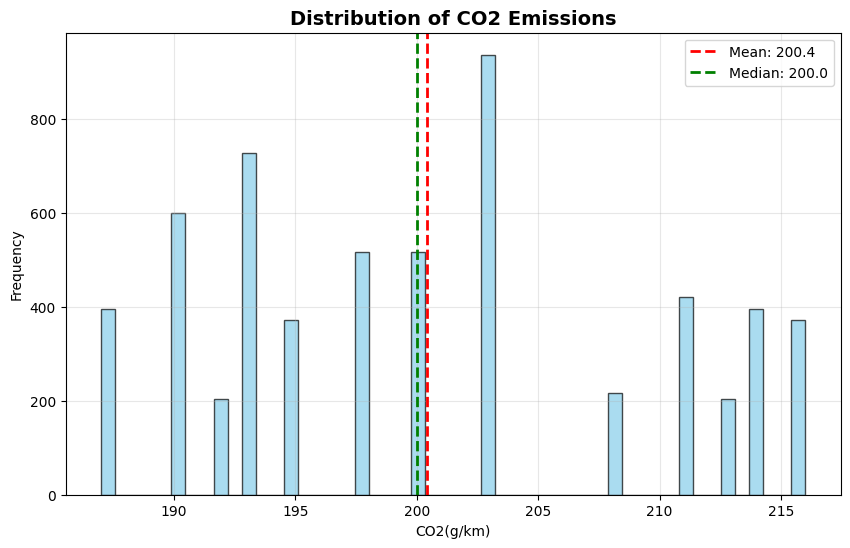

In [228]:
plt.figure(figsize=(10, 6))
plt.hist(df_Viano2['CO2(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(df_Viano2['CO2(g/km)'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_Viano2["CO2(g/km)"].mean():.1f}')
plt.axvline(df_Viano2['CO2(g/km)'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df_Viano2["CO2(g/km)"].median():.1f}')
plt.title('Distribution of CO2 Emissions', fontsize=14, fontweight='bold')
plt.xlabel('CO2(g/km)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### General Overview and Distribution of Data Variables


- The dataset is imbalanced with respect to <span style="color:red">Brand & Model </span> attributes, being heavily dominated by specific values.
    - 85.7% of the dataset consists of Mercedes vehicles
    - 72% of the dataset comprises the following 3 Mercedes models:
        - VIANO: 14031 (31.3%)
        - VITO: 9890 (22.1%)
        - SPRINTER: 8323 (18.6%)

- They look very similar to eachother The records listed under similar <span style="color:red">Commercial names</span> require further investigation to determine their distinctions, as they appear to be quite similar:
    - VIANO 2.2 CDI: 5874 (13.1%)
    - VIANO 2.0 CDI: 3903 (8.7%)
    - COMBI 116 CDI: 3754 (8.4%)
    - COMBI 113 CDI: 2620 (5.8%)
    - VIANO 3.0 CDI: 1608 (3.6%)



- Can we clarify or translate the <span style="color:red">Gearbox</span> attribute values? Specifically
    - What do the respective codes represent? For example, Is M6 equivalent to "Manual 6-speed"?
- Current distribution:
    - M 6: 19364 (43.2%)
    - A 5: 13770 (30.7%)
    - A 7: 8428 (18.8%)

- How should we interpret <span style="color:red">Field_V9</span> attribute as the top 3 values are covering 80.2% of the dataset? Can we deduct something from the respective values?
   - 715/2007*692/2008EURO5: 26426 (59.2%)
   - 715/2007*566/2011EURO5: 8250 (18.5%)
   - 715/2007*630/2012EURO5: 3332 (7.5%)

## Ideas

Similar Brand+Models (mostly Mercedes ones) could be removed to balance the dataset to simplify and bring balance to the dataset. It should be investigated further.

<span style="font-size: 16px">

#### 2023 Europe Data Frame 1st Exploration

In [136]:
"""
df_emm.shape
"""

'\ndf_emm.shape\n'

In [137]:
"""
df_emm
"""

'\ndf_emm\n'

In [138]:
"""
df_emm.isna().sum()
"""

'\ndf_emm.isna().sum()\n'

In [139]:
"""
df_emm.duplicated().sum()
"""

'\ndf_emm.duplicated().sum()\n'

## TARGET VARIABLE ANALYSIS: CO2 (g/km)

In [140]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df['CO2(g/km)'].describe())

count    44811.000000
mean       198.910892
std         39.014678
min         27.000000
25%        187.000000
50%        203.000000
75%        221.000000
max        572.000000
Name: CO2(g/km), dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/203394776.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


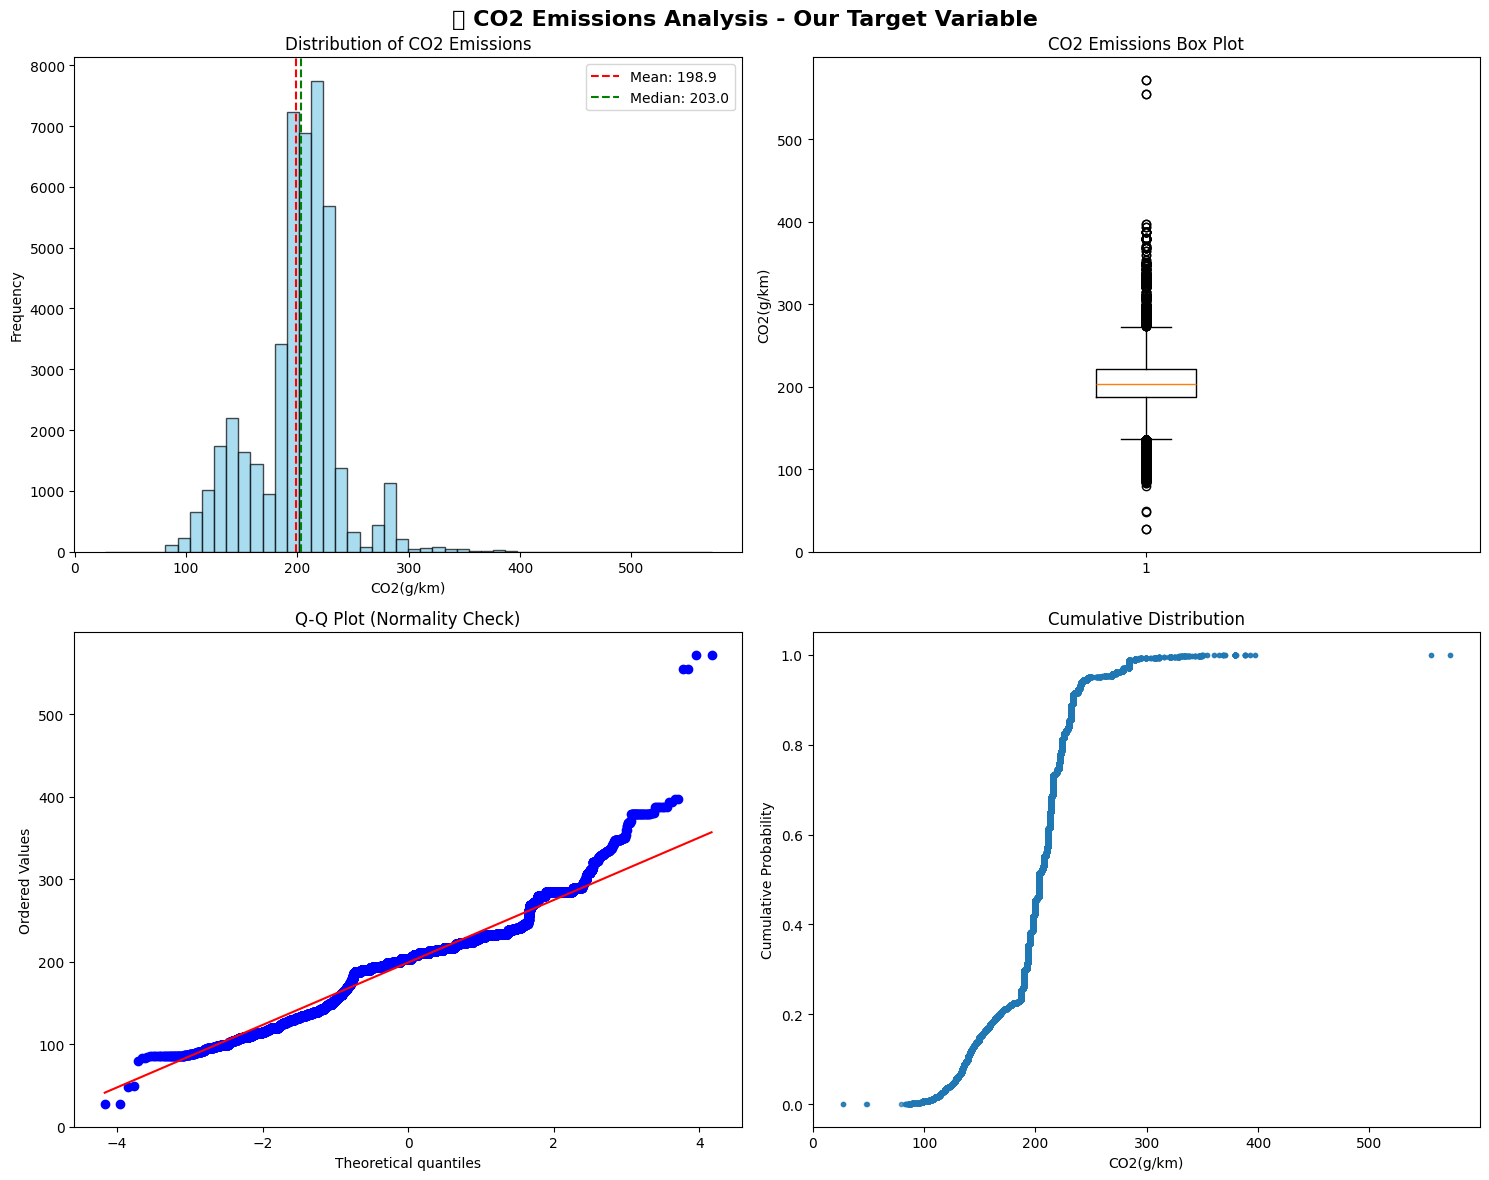

In [141]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df['CO2(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df['CO2(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df["CO2(g/km)"].mean():.1f}')
axes[0,0].axvline(df['CO2(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df["CO2(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df['CO2(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2(g/km)')

# Q-Q plot for normality
stats.probplot(df['CO2(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')

# Cumulative distribution
sorted_co2 = np.sort(df['CO2(g/km)'].dropna())
y = np.arange(1, len(sorted_co2) + 1) / len(sorted_co2)
axes[1,1].plot(sorted_co2, y, marker='.', linestyle='none', alpha=0.7)
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('CO2(g/km)')
axes[1,1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


Q-Q PLOT: The data follows a normal distribution so it is approximately normal enough for most statistical analyses.

Cumulative Distribution: It should be rechecked. I didn't figure out how to interpret (Burak)

Those consumptions above 400 are real and not outliers.

## **Correlation between variables**

### Correlation matrix

In [142]:
df_num = df.select_dtypes(include='number').corr()

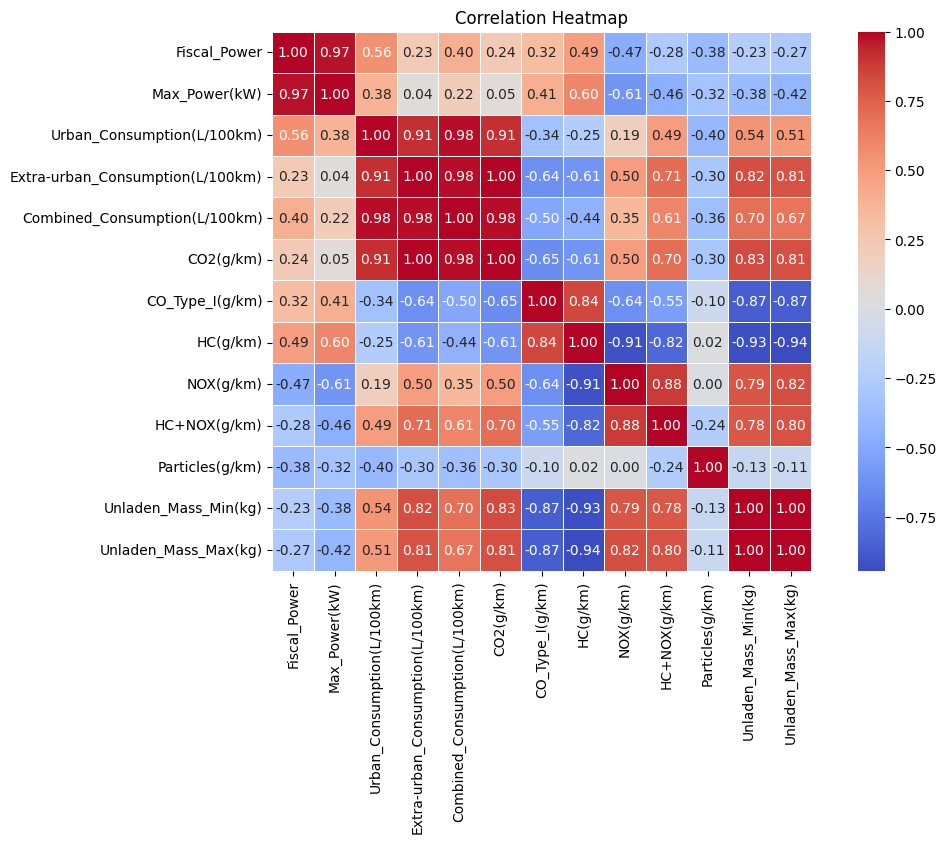

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
df_corr_matrix = df_num.corr()


sns.heatmap(df_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### <span style="color:red">The correlation above should be discarded </span>

The issue in your the is that we are applying .corr() twice, which is causing the problem:
df_num = df.select_dtypes(include='number').corr()
df_corr_matrix = df_num.corr()

The CO2 seems to be: <br> 
- high positiv correlated with the Car Maximum Mass and <br>
"HC + NOX" 
- negatively correlated with CO Type I and HC. <br>
ATTENTION: It's a bit strange that these last two are negatively correlated with CO2. 

Correlation with CO2 emissions:
CO2(g/km)                           1.000000
Extra-urban_Consumption(L/100km)    0.970792
Combined_Consumption(L/100km)       0.959571
Urban_Consumption(L/100km)          0.907357
Unladen_Mass_Min(kg)                0.695331
Unladen_Mass_Max(kg)                0.685936
HC+NOX(g/km)                        0.673189
Fiscal_Power                        0.480768
Max_Power(kW)                       0.361228
NOX(g/km)                           0.264285
Particles(g/km)                     0.053874
CO_Type_I(g/km)                    -0.132099
HC(g/km)                           -0.326438
Name: CO2(g/km), dtype: float64


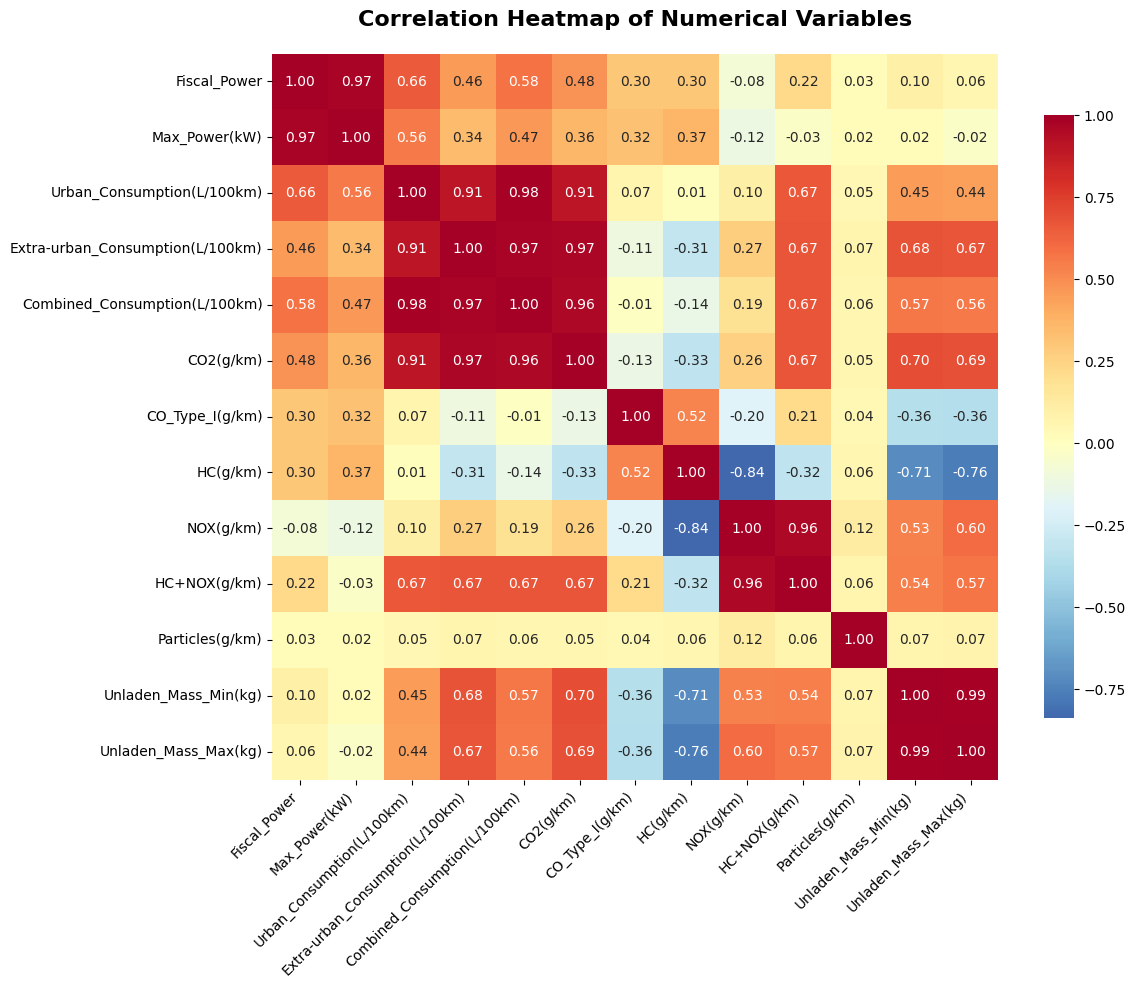

In [234]:
#key_numerical = ['Fiscal_Power', 'Max_Power(kW)', 'Urban_Consumption(L/100km)', 'Extra-urban_Consumption(L/100km)','Combined_Consumption(L/100km)', 'CO_Type_I',
                # 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)', 'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)']
numerical_cols = df.select_dtypes(include=[np.number]).columns

#display(numerical_cols)
corr_with_co2 = df[numerical_cols].corr()['CO2(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

# Create correlation matrix for all numerical columns
correlation_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation with CO2 emissions:
CO2(g/km)                           1.000000
Extra-urban_Consumption(L/100km)    0.970792
Combined_Consumption(L/100km)       0.959571
Urban_Consumption(L/100km)          0.907357
Unladen_Mass_Min(kg)                0.695331
Unladen_Mass_Max(kg)                0.685936
HC+NOX(g/km)                        0.673189
Fiscal_Power                        0.480768
Max_Power(kW)                       0.361228
NOX(g/km)                           0.264285
Particles(g/km)                     0.053874
CO_Type_I(g/km)                    -0.132099
HC(g/km)                           -0.326438
Name: CO2(g/km), dtype: float64


/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/3150502464.py:43: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


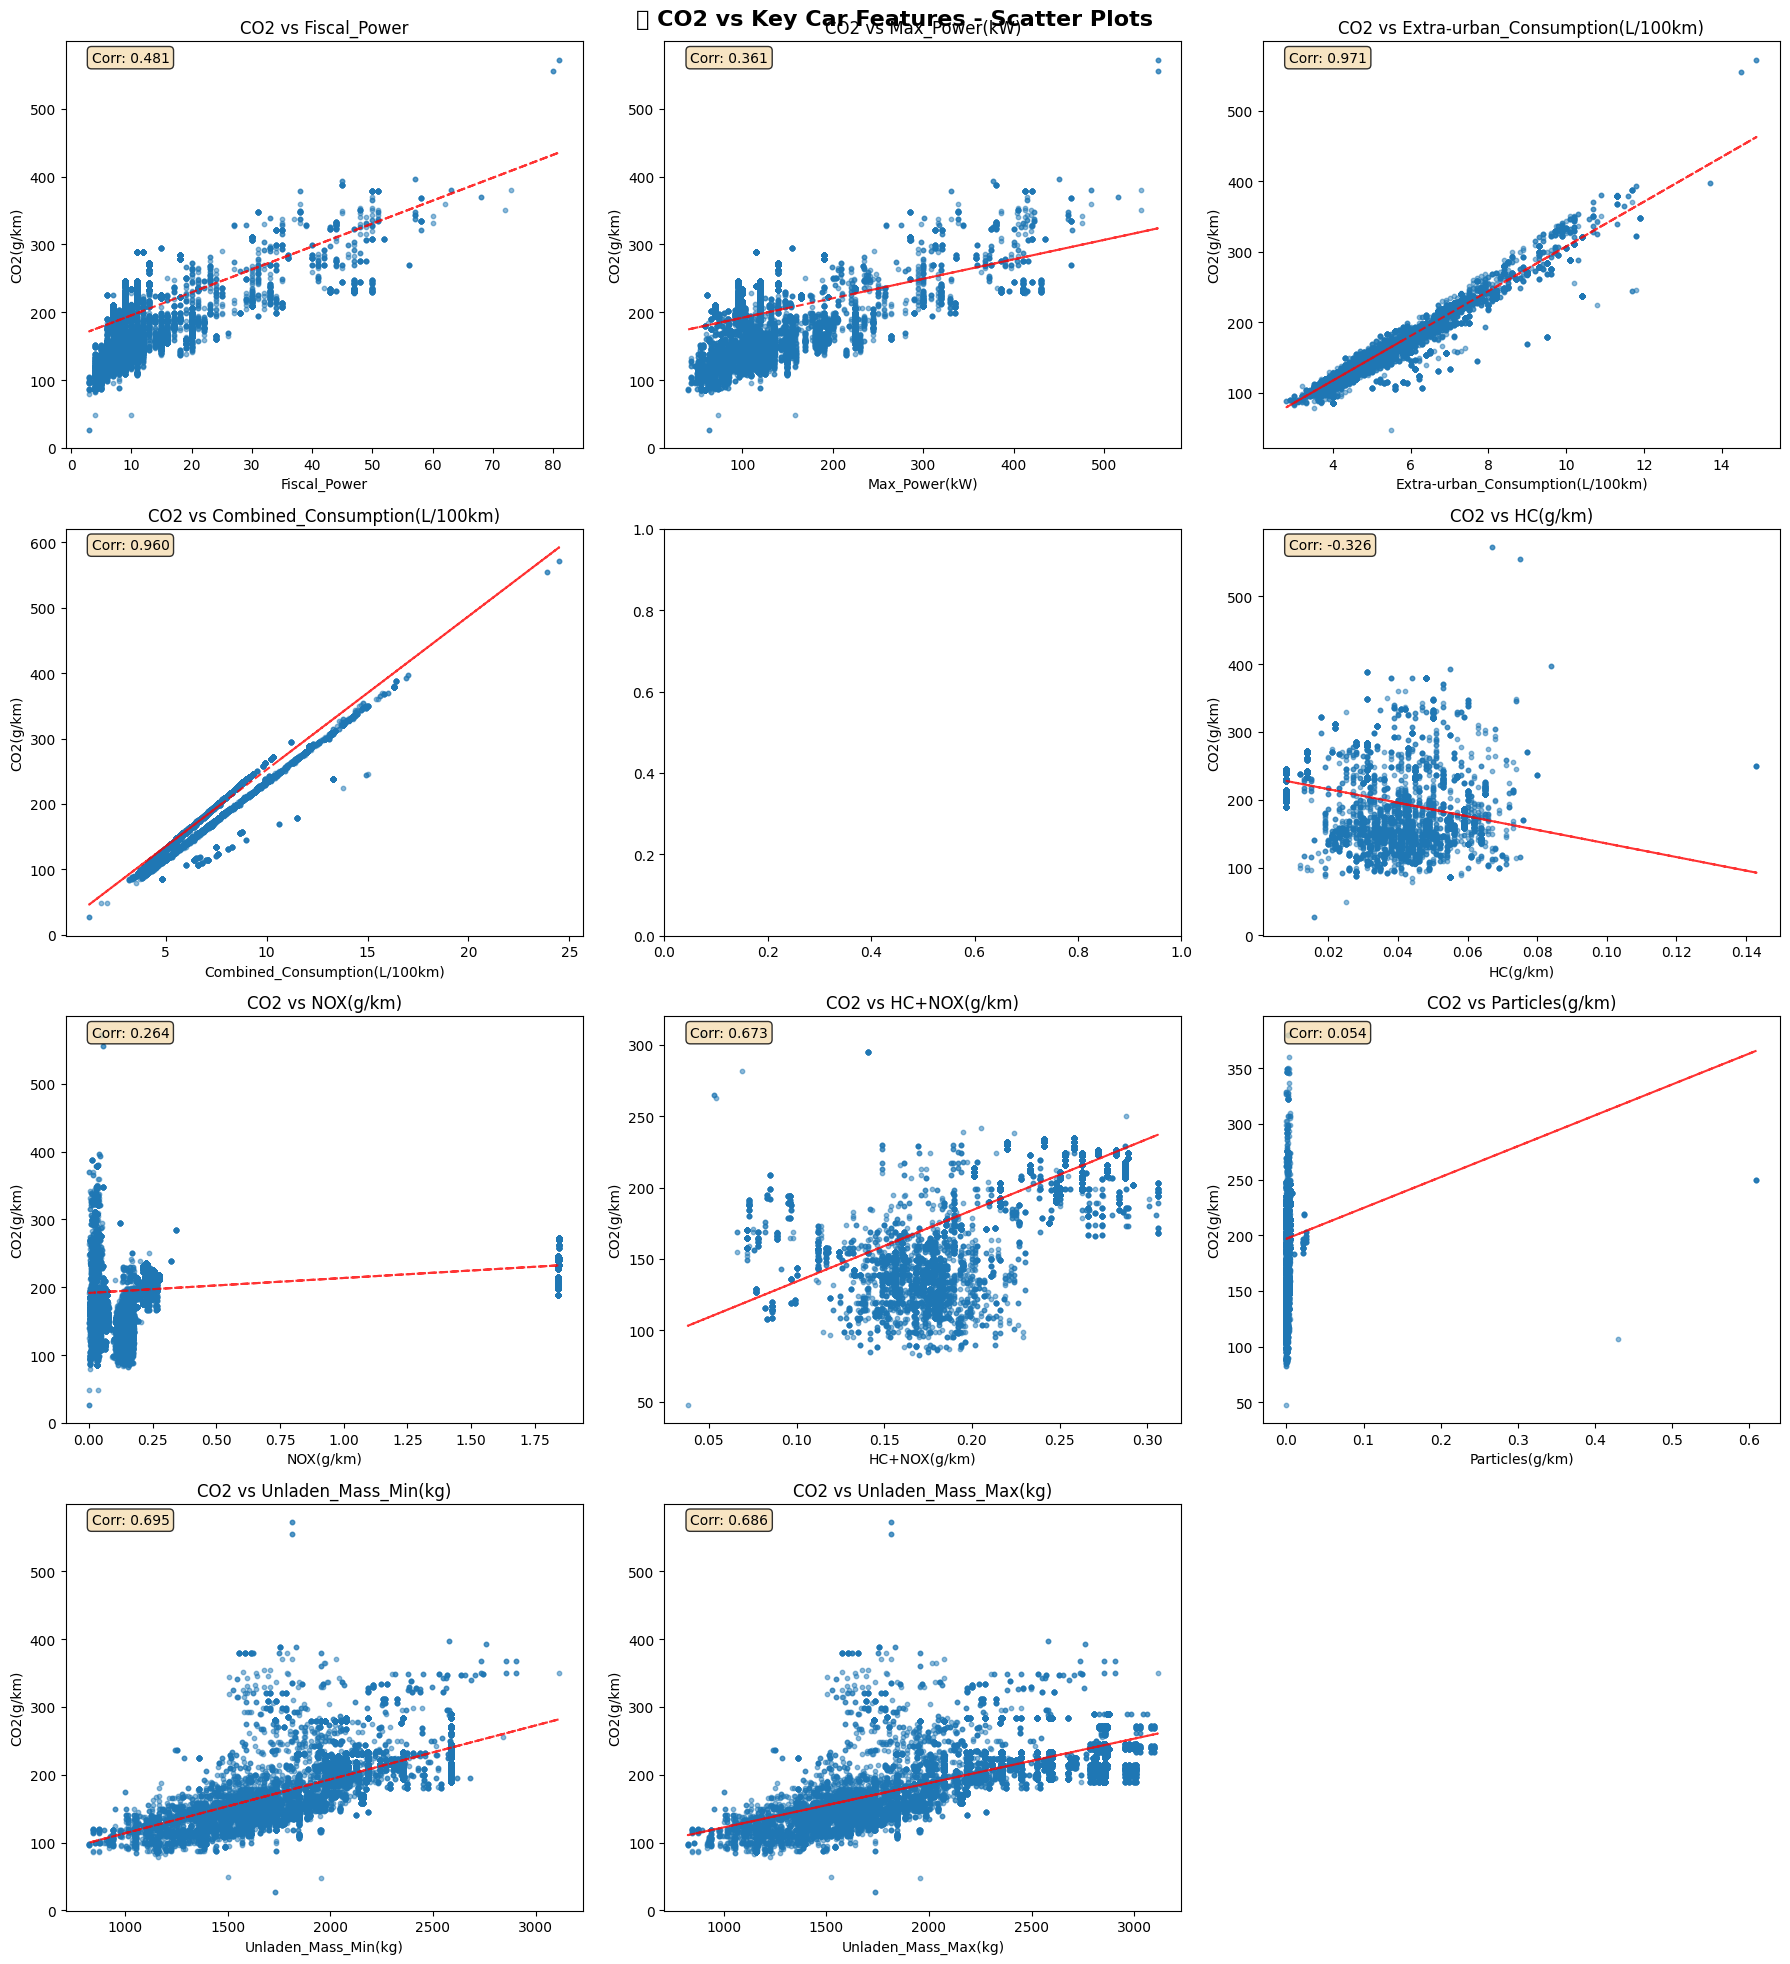

In [181]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fiscal_Power', 'Max_Power(kW)', 'Extra-urban_Consumption(L/100km)','Combined_Consumption(L/100km)', 'CO_Type_I',
                 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)', 'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)']
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_with_co2 = df[numerical_cols].corr()['CO2(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('🔍 CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df.columns:
        clean_data = df[[feature, 'CO2(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2(g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [182]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Critical Error

vif["Variable"] = df_num.columns 

here df_num is defined as df_num = df.select_dtypes(include='number').corr() . Correlation part is mixing the values

In [183]:
# VIF calculation
vif = pd.DataFrame()
vif["Variable"] = df_num.columns
vif["VIF"] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]

print(vif)

                            Variable           VIF
0                       Fiscal_Power  2.247420e+04
1                      Max_Power(kW)  1.751192e+04
2         Urban_Consumption(L/100km)  3.173689e+06
3   Extra-urban_Consumption(L/100km)  2.149112e+06
4      Combined_Consumption(L/100km)  1.079079e+07
5                          CO2(g/km)  2.347924e+04
6                    CO_Type_I(g/km)  9.487487e+01
7                           HC(g/km)  5.946665e+03
8                          NOX(g/km)  1.609529e+03
9                       HC+NOX(g/km)  6.921638e+02
10                   Particles(g/km)  5.913185e+01
11              Unladen_Mass_Min(kg)  2.521753e+04
12              Unladen_Mass_Max(kg)  2.848056e+04


With this we can conclude adjustment for the next variables
1. Urban, Extra-urban, and Combined Consumption are high correlated <br>
 with CO2
Suggestion: In the future for the analysis with the EEA Data base, <br> 
maybe would be ok if we just keep CO2 Consumption
2. Max_Power vs Fiscal_Power are almost the same
Suggestion: Keep only one (e.g., Max_Power(kW)<br>
 is more physically 
 meaningful)
3. Unladen Mass Min vs Max: Close to be redundant
Suggestion: Keep max
4. Pollutant Gases (NOX, HC, Particles, HC+NOX)
Sggestion: in the future if we concentrate in CO2 pollution, <br>
we could drop them



After studying the correlation, we might think the following numerical variables for the model

- Max_Power(kW)
- Unladen_Mass_Max(kg)
- NOX(g/km), HC+NOX(g/km) (should be investigated further before the final decision)


Potential Categorical Variable that could be used in the model

- Fuel_Type
- Hybrid
- Gearbox
- Body_Type
- Segment


In [236]:
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

### Correlation of Variables

#### Does Fuel Type has a relationship with CO2 Emmissions

In order to see if the Maximal Mass has an influence in the CO2, we should <br>
differentiate those cars that use Gasoline/Diesel and the electric ones. Lets <br>
make first an exploration of how is the data of fuel type

In [188]:
df['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
GO       0.842319
ES       0.137280
EH       0.004437
ES/GN    0.003924
GN/ES    0.003924
ES/GP    0.002230
GP/ES    0.002230
GN       0.001315
GH       0.001204
EL       0.000870
FE       0.000178
EE       0.000067
GL       0.000022
Name: proportion, dtype: float64

The first 3 Categories (GO, ES and EH) are already the 97% <br>
of the cars total. <br>
85% of the cars are driven with gasoline <br>
and 13% are diesel, below the 1% is hybrid

In [189]:
df['Fuel_Type'].value_counts(normalize=True).keys()[0:3]



Index(['GO', 'ES', 'EH'], dtype='object', name='Fuel_Type')

On the internet we could figure out, what GO, ES and EH mean

In [190]:
labels = {"GO": "Gasoline", "ES":"Diesel", "EH": "hybrid"}

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/1218593849.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])


Text(0.5, 1.0, 'CO₂ Emissions by Fuel Type')

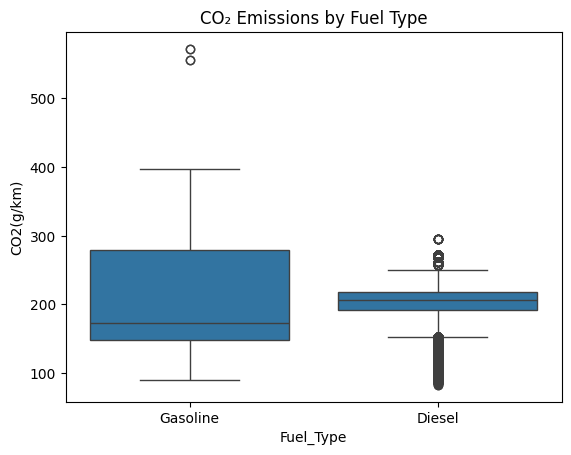

In [191]:
df_filter = df[(df['Fuel_Type'] == 'ES') | (df['Fuel_Type'] == 'GO')]

fig = sns.boxplot(x=df_filter['Fuel_Type'], y=df_filter['CO2(g/km)'])

fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])

plt.title('CO₂ Emissions by Fuel Type')


The mean between gasoline and diesel has a difference, is this <br>
a significant difference? <br>

let's apply Welch's t-test in order to respond this question:<br>
<br>
    - H0: There is no significant difference in the CO2 Consumption<br>
    levels between Gasoline and Diesel.<br>
    <br>
    - H1: There is a significant difference in the CO2 Consumption <br>
    levels between Gasoline and Diesel.<br>
        

In [192]:
from scipy.stats import ttest_ind

# Filter CO₂ data for each fuel type
es_co2 = df_filter[df_filter['Fuel_Type'] == 'ES']['CO2(g/km)']
go_co2 = df_filter[df_filter['Fuel_Type'] == 'GO']['CO2(g/km)']

# Apply Welch's t-test (does not assume equal variances)
t_stat, p_value = ttest_ind(es_co2, go_co2, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value>0.05:
    print("p_value>0.05 Fail to reject the null (not significant difference)")
else:
    print("p_value<0.05 Reject the null hypothesis (significant difference)")

T-statistic: 0.3724281026518655
p-value: 0.7095860630521096
p_value>0.05 Fail to reject the null (not significant difference)


#### Does Maximal mass has a relationship with CO2 Emmissions

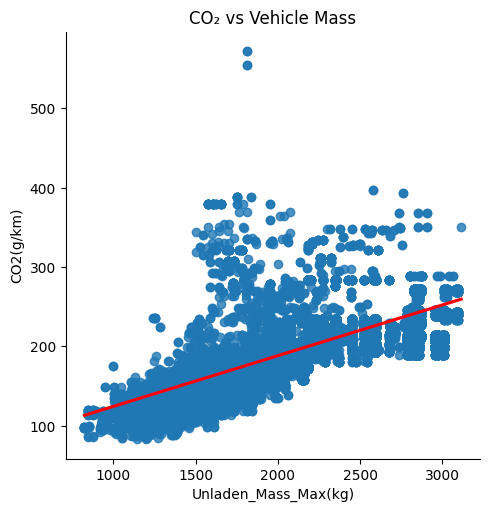

In [193]:
sns.lmplot(x='Unladen_Mass_Max(kg)', y='CO2(g/km)',
           line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Vehicle Mass')
plt.show()

it seems to be a relationship between Mass and CO2 <br>

let's make "Pearson's r" test perform to see if there is a linear <br>
correlation

In [194]:
# Example: mass vs CO2
from scipy.stats import pearsonr
r, p = pearsonr(df_filter['Unladen_Mass_Max(kg)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)


Correlation coefficient (r): 0.6724436516215779
p-value: 0.0


The r value is high so there is strong positive correlation <br>
and the p-value: < 0.05, so it is significant the relationship <br>
so: Does Maximal mass has a relationship with CO2 Emissions?<br>
YES it has a strong positive relationship

#### Does the gear box type has a relationship with CO2 Emmisions?

In [195]:
df_filter['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.438671
A 5    0.308797
A 7    0.188506
M 5    0.025265
A 6    0.024878
A 8    0.009764
V 0    0.001343
D 5    0.000888
A 4    0.000865
D 7    0.000478
M 7    0.000273
D 6    0.000250
S 6    0.000023
Name: proportion, dtype: float64

In [196]:
df_filter

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12.0,147.0,...,0.052,0.032,NaN,0.002,1505.0,1505.0,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9.0,125.0,...,NaN,0.169,0.190,0.003,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9.0,125.0,...,NaN,0.164,0.193,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10.0,120.0,...,NaN,0.116,0.152,0.000,1799.0,1799.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9.0,120.0,...,NaN,0.106,0.144,0.000,1786.0,1786.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9.0,120.0,...,NaN,0.108,0.132,0.001,1726.0,1726.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9.0,120.0,...,NaN,0.127,0.152,0.001,1706.0,1706.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE


In [197]:
main_gb = ['M 6','A 5','A 7'] #90% of the data falls into these three categories

df_filter_mgb = df_filter[df_filter['Gearbox'].isin(main_gb)]


In [198]:
df_filter_mgb['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.468679
A 5    0.329921
A 7    0.201401
Name: proportion, dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/298571972.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])


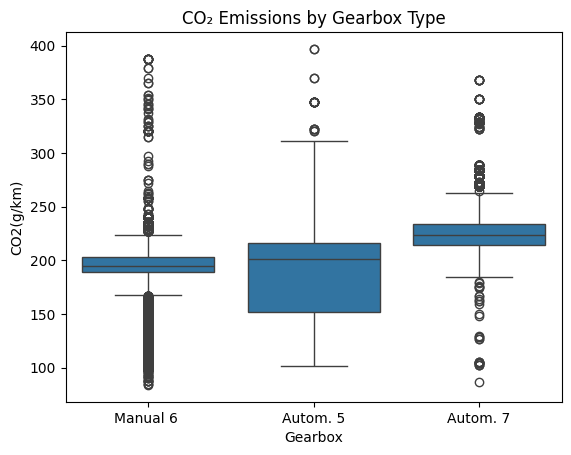

In [199]:

fig = sns.boxplot(x=df_filter_mgb['Gearbox'], y=df_filter_mgb['CO2(g/km)'])

fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])
plt.title('CO₂ Emissions by Gearbox Type')

plt.show()


Between Manual and automatic 5 (5 gears) there is a slightly <br>
difference in the mean. The automatic 7 has a higher mean than the<br>
other two. But is it this difference due to the gearbox type <br>
or because this 'gearbox' type are mainly to see in "sport" cars <br>
or  in cars bigger than standard cars? <br>. In those cases the <br> 
cylinders are bigger and therefore more CO2 consumption?


In [200]:
df_filter_mgb[df_filter_mgb['Gearbox'] == 'A 7']['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.412340
BERLINE                0.243057
BREAK                  0.143927
COUPE                  0.064598
TS TERRAINS/CHEMINS    0.062545
CABRIOLET              0.033084
MONOSPACE COMPACT      0.028013
COMBISPACE             0.012437
Name: proportion, dtype: float64

We don't see really a pattern

#### Does the segment has a relationship with CO2 Consumption?

In [201]:
df_filter['Segment'].value_counts(normalize=True)

Segment
MOY-INFER     0.458382
MOY-SUPER     0.344008
LUXE          0.114100
SUPERIEURE    0.044338
INFERIEURE    0.034915
ECONOMIQUE    0.004211
MOY-INF       0.000046
Name: proportion, dtype: float64

In [202]:
main_seg = df_filter["Segment"].value_counts().index[:4]

main_seg

Index(['MOY-INFER', 'MOY-SUPER', 'LUXE', 'SUPERIEURE'], dtype='object', name='Segment')

In [203]:
df_filter_seg = df[df["Segment"].isin(main_seg)]

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/627092353.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])


[Text(0, 0, 'Lower-Mid Segment'),
 Text(1, 0, 'Upper-Mid Segment '),
 Text(2, 0, 'Luxury'),
 Text(3, 0, 'Upper Segment')]

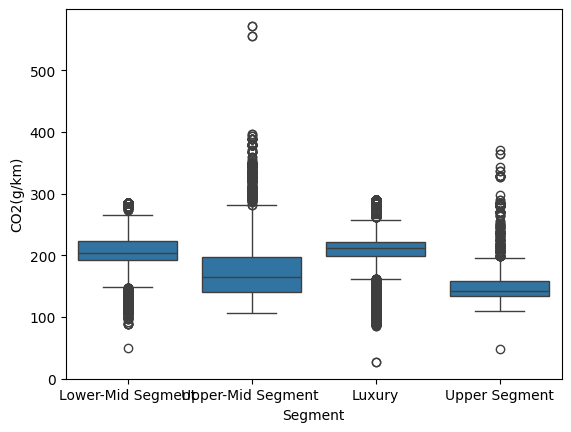

In [204]:

fig = sns.boxplot(x=df_filter_seg['Segment'], y=df_filter_seg['CO2(g/km)'])

fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])



#### Does Max Power has a relationship with CO2 Consumption?

In [205]:
df_filter['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.740731
BERLINE                0.103539
BREAK                  0.051303
TS TERRAINS/CHEMINS    0.027518
COUPE                  0.024969
COMBISPACE             0.019051
CABRIOLET              0.013725
MONOSPACE COMPACT      0.013429
MINISPACE              0.003141
MONOSPACE              0.002595
Name: proportion, dtype: float64

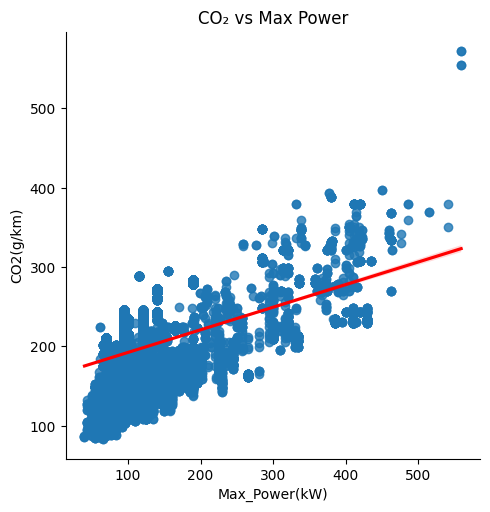

In [206]:
sns.lmplot(x='Max_Power(kW)', y='CO2(g/km)',
            line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Max Power')
plt.show()

The Max Power seems to be strongly related with CO2 emmsion, this <br>
makes sense because 
is also other hypothesis we have to explore

In [207]:
# Mass vs CO2
r, p = pearsonr(df_filter['Max_Power(kW)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): 0.3646880782020383
p-value: 0.0


it has a moderate relationship, not strong as <br>
mass though.<br>
This makes sense mechanically too — heavier cars naturally <br>
require more fuel, regardless of how powerful the engine is.

#### Does Body Type has a relationship with CO2 Consumption?

In [208]:
main_bt = df_filter['Body_Type'].value_counts(normalize=True).index[:5]
main_bt

Index(['MINIBUS', 'BERLINE', 'BREAK', 'TS TERRAINS/CHEMINS', 'COUPE'], dtype='object', name='Body_Type')

In [209]:
#filter main body types (for visualisation)
df_filter_bt = df_filter[df_filter['Body_Type'].isin(main_bt)]

In [210]:
df_filter_bt['Body_Type'].value_counts()

Body_Type
MINIBUS                32544
BERLINE                 4549
BREAK                   2254
TS TERRAINS/CHEMINS     1209
COUPE                   1097
Name: count, dtype: int64

In [211]:
df_filter_seg['Body_Type'].isnull().sum()


np.int64(0)

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/2922057836.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


[Text(0, 0, 'Station Wagon'),
 Text(1, 0, 'Sedan '),
 Text(2, 0, 'Convertible'),
 Text(3, 0, 'Coupe'),
 Text(4, 0, 'SUV'),
 Text(5, 0, 'MPV'),
 Text(6, 0, 'Minivan_Comp.'),
 Text(7, 0, 'Minibus'),
 Text(8, 0, 'Ut_Van')]

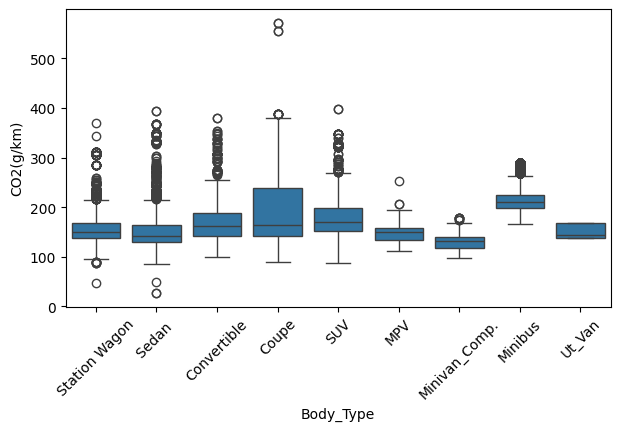

In [212]:

fig = sns.boxplot(x=df_filter_seg['Body_Type'], y=df_filter_seg['CO2(g/km)'])

plt.xticks(rotation=45)

plt.tight_layout()



fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


In [213]:
from scipy.stats import f_oneway

groups = [
    group['CO2(g/km)'].dropna()
    for name, group in df_filter.groupby('Body_Type')
]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3832.5821432623975
p-value: 0.0


In [214]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_filter['CO2(g/km)'], groups=df_filter['Body_Type'], alpha=0.05)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
          BERLINE               BREAK  10.9492    0.0   8.6232  13.2753   True
          BERLINE           CABRIOLET  24.5952    0.0  20.6817  28.5088   True
          BERLINE          COMBISPACE   1.8308 0.7927  -1.5655   5.2272  False
          BERLINE               COUPE  47.4919    0.0  44.4544  50.5293   True
          BERLINE             MINIBUS  64.4797    0.0  63.0503  65.9091   True
          BERLINE           MINISPACE -19.9233    0.0 -27.7261 -12.1205   True
          BERLINE           MONOSPACE   0.4001    1.0  -8.1628   8.9631  False
          BERLINE   MONOSPACE COMPACT -18.6075    0.0  -22.559 -14.6561   True
          BERLINE TS TERRAINS/CHEMINS  31.6993    0.0  28.7774  34.6212   True
            BREAK           CABRIOLET   13.646    0.

In [215]:
df_filter['Body_Type'].isnull().sum()

np.int64(0)

In [216]:
df_filter['CO2(g/km)'].isnull().sum()

np.int64(0)